In [ ]:

from google.colab import files
import os
import zipfile

# Upload kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()   # a file picker will appear


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [ ]:

# Place it where Kaggle CLI expects it
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)   # required permissions


In [ ]:


# Install Kaggle CLI and download the dataset
os.system("pip install -q kaggle")
os.system("kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo")

0

In [ ]:
# Unzip
zip_path = "database-for-emotion-recognition-system-gameemo.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")

print("\nDone! Dataset extracted.")
print("Folders found:", [f for f in os.listdir(".") if os.path.isdir(f)])


Done! Dataset extracted.
Folders found: ['.config', 'GAMEEMO', 'sample_data']


In [ ]:
!pip install giotto-tda scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not curr

In [ ]:
import numpy as np
import pandas as pd
import os, glob, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy, NumberOfPoints, BettiCurve
from gtda.diagrams import Scaler as DiagramScaler
from gtda.curves import StandardFeatures

In [ ]:

# ── CELL 4: Config ────────────────────────────────────────────────
DATA_DIR = "./GAMEEMO"

CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]

EMOTIONS = {"G1": "Boring", "G2": "Calm", "G3": "Horror", "G4": "Funny"}
EMOTION_LABELS = list(EMOTIONS.values())

# Per-channel embedding params — each channel finds its own optimal
# time_delay/dimension via "search", but search runs SEPARATELY on
# the train signal and the test signal (each only sees its own data)
TIME_DELAY = 2   # starting guess for search
DIMENSION  = 3   # starting guess for search

SW_SIZE       = 20
SW_STRIDE     = 10
HOMOLOGY_DIMS = (0, 1)
BETTI_BINS    = 10

TEST_SIZE  = 0.2
RANDOM_STATE = 42

In [ ]:
#CELL 5: Load one subject's data ───────────────────────────────
def load_subject(subject_id):
    all_X, all_y = [], []

    csv_dir = os.path.join(
        DATA_DIR,
        f"(S{subject_id:02d})",
        "Preprocessed EEG Data",
        ".csv format"
    )

    for game_tag in EMOTIONS:
        label = list(EMOTIONS.keys()).index(game_tag)
        fname = f"S{subject_id:02d}{game_tag}AllChannels.csv"
        fpath = os.path.join(csv_dir, fname)

        if not os.path.exists(fpath):
            print(f"  [warn] not found: {fname}")
            continue

        df   = pd.read_csv(fpath)
        cols = [c for c in df.columns if c in CHANNELS]
        if not cols:
            cols = df.select_dtypes(include=np.number).columns[:14].tolist()

        data = df[cols].values.astype(np.float64)
        all_X.append(data)                                    # keep as separate block
        all_y.append(np.full(len(data), label, dtype=int))

    if not all_X:
        raise FileNotFoundError(f"No CSVs found for S{subject_id:02d}")

    # Return list of (X_block, y_block) per emotion — NOT concatenated.
    # Concatenating here and splitting 80/20 afterwards would put the
    # entire test set inside the last emotion block (G4/Funny) only.
    return all_X, all_y



In [ ]:

# ── CELL 6: Birth/Death/Lifetime stats ───────────────────────────
def persistence_stats(X_pd):
    n_windows = X_pd.shape[0]
    all_rows  = []
    for w in range(n_windows):
        row = []
        for dim in HOMOLOGY_DIMS:
            pts    = X_pd[w][X_pd[w, :, 2] == dim]
            finite = pts[np.isfinite(pts[:, 1])]
            if len(finite) == 0:
                row.extend([0.0] * 6)
            else:
                b = finite[:, 0]
                d = finite[:, 1]
                l = d - b
                row.extend([b.mean(), b.std(), d.mean(), d.std(), l.mean(), l.std()])
        all_rows.append(row)
    return np.array(all_rows)


In [ ]:

# ── CELL 7: TDA features for one channel split ───────────────────
def tda_on_signal(signal, labels):
    """
    Run TDA pipeline on a 1-D signal. Each call independently searches
    for the optimal time_delay/dimension for THIS signal only — so when
    called separately on train and test, there's no leakage between them.

    signal : (T,)
    labels : (T,)

    Returns
    -------
    X_feat : (n_windows, 28)
    y_win  : (n_windows,)
    """
    # Step 1 — SingleTakensEmbedding, per-channel optimal params via search.
    # "search" looks ONLY at the signal passed in here — when called on the
    # train split it never sees test data, and vice versa.
    STE = SingleTakensEmbedding(
        parameters_type="search",
        time_delay=TIME_DELAY,
        dimension=DIMENSION,
        n_jobs=-1,
    )
    X_emb, y_emb = STE.fit_transform_resample(signal, labels)

    # Step 2 — SlidingWindow over embedded point cloud
    SW = SlidingWindow(size=SW_SIZE, stride=SW_STRIDE)
    X_win, y_win = SW.fit_transform_resample(X_emb, y_emb)

    # Step 3 — VietorisRipsPersistence
    VR   = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=-1)
    X_pd = VR.fit_transform(X_win)
    X_pd = DiagramScaler().fit_transform(X_pd)

    # Step 4 — All persistence features
    feat_bdl = persistence_stats(X_pd)                                          # (n_win, 12)
    feat_pe  = PersistenceEntropy(normalize=True, nan_fill_value=0.0).fit_transform(X_pd)  # (n_win, 2)
    feat_amp = Amplitude(metric="landscape", order=None).fit_transform(X_pd)   # (n_win, 2)
    feat_np  = NumberOfPoints().fit_transform(X_pd)                            # (n_win, 2)
    betti    = BettiCurve(n_bins=BETTI_BINS).fit_transform(X_pd)
    feat_bc  = StandardFeatures().fit_transform(betti)                         # (n_win, 10)

    X_feat = np.hstack([feat_bdl, feat_pe, feat_amp, feat_np, feat_bc])       # (n_win, 28)
    return X_feat, y_win

In [ ]:

# ── CELL 8: Extract features from one subject ─────────────────────
def extract_subject_features(subject_id):
    """
    Load subject data as separate emotion blocks. For EACH emotion block,
    split 80/20 on its own raw timepoints (so train and test both contain
    all 4 emotions), then run TDA on train and test signals separately.
    Returns pooled train and test feature matrices for this subject.
    """
    blocks_X, blocks_y = load_subject(subject_id)

    # Split each emotion block 80/20 individually, then stitch the splits
    # back together per channel — this keeps the time series CONTIGUOUS
    # within each emotion (needed for Takens embedding) while ensuring
    # both train and test contain samples from all 4 emotions.
    tr_blocks_X, tr_blocks_y = [], []
    te_blocks_X, te_blocks_y = [], []

    for X_block, y_block in zip(blocks_X, blocks_y):
        n = len(y_block)
        split_idx = int(n * 0.8)
        tr_blocks_X.append(X_block[:split_idx])
        tr_blocks_y.append(y_block[:split_idx])
        te_blocks_X.append(X_block[split_idx:])
        te_blocks_y.append(y_block[split_idx:])

    X_tr_all, y_tr_all = [], None
    X_te_all, y_te_all = [], None
    min_tr, min_te     = None, None

    n_channels = blocks_X[0].shape[1]

    for ch_idx in range(n_channels):
        ch = CHANNELS[ch_idx]
        print(f"  S{subject_id:02d} [{ch_idx+1:02d}/14] {ch} ...", end=" ", flush=True)
        try:
            feat_tr_parts, y_tr_parts = [], []
            feat_te_parts, y_te_parts = [], []

            # Run TDA separately on EACH emotion's train slice and test slice,
            # then stack results across emotions for this channel.
            for X_tr_b, y_tr_b, X_te_b, y_te_b in zip(
                tr_blocks_X, tr_blocks_y, te_blocks_X, te_blocks_y
            ):
                f_tr, yw_tr = tda_on_signal(X_tr_b[:, ch_idx], y_tr_b)
                f_te, yw_te = tda_on_signal(X_te_b[:, ch_idx], y_te_b)
                feat_tr_parts.append(f_tr)
                y_tr_parts.append(yw_tr)
                feat_te_parts.append(f_te)
                y_te_parts.append(yw_te)

            feat_tr = np.vstack(feat_tr_parts)
            y_tr_win = np.concatenate(y_tr_parts)
            feat_te = np.vstack(feat_te_parts)
            y_te_win = np.concatenate(y_te_parts)

            X_tr_all.append(feat_tr)
            X_te_all.append(feat_te)

            if y_tr_all is None:
                y_tr_all = y_tr_win
                y_te_all = y_te_win
                min_tr   = feat_tr.shape[0]
                min_te   = feat_te.shape[0]
            else:
                min_tr = min(min_tr, feat_tr.shape[0])
                min_te = min(min_te, feat_te.shape[0])

            print(f"tr_wins={feat_tr.shape[0]}, te_wins={feat_te.shape[0]}")
        except Exception as e:
            print(f"SKIPPED — {e}")

    if not X_tr_all:
        return None, None, None, None

    X_tr = np.hstack([f[:min_tr] for f in X_tr_all])
    X_te = np.hstack([f[:min_te] for f in X_te_all])
    y_tr = y_tr_all[:min_tr]
    y_te = y_te_all[:min_te]

    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

    return X_tr, y_tr, X_te, y_te



In [ ]:

# ── CELL 9: Confusion matrix plot ─────────────────────────────────
def plot_cm(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTION_LABELS,
                yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [ ]:

# ── CELL 10: Collect features from all subjects ───────────────────
print("Extracting TDA features from all subjects...")

all_X_tr, all_y_tr = [], []
all_X_te, all_y_te = [], []

for sid in range(1, 5):
    print(f"\n{'='*50}")
    print(f"Subject S{sid:02d}")
    print(f"{'='*50}")
    try:
        X_tr, y_tr, X_te, y_te = extract_subject_features(sid)
        if X_tr is not None:
            all_X_tr.append(X_tr)
            all_y_tr.append(y_tr)
            all_X_te.append(X_te)
            all_y_te.append(y_te)
    except FileNotFoundError as e:
        print(f"  [skip] {e}")
    except Exception as e:
        print(f"  [error] {e}")

# Pool all subjects together
X_train = np.vstack(all_X_tr)
y_train = np.concatenate(all_y_tr)
X_test  = np.vstack(all_X_te)
y_test  = np.concatenate(all_y_te)

print(f"\nTrain : {X_train.shape}  |  Test : {X_test.shape}")


Extracting TDA features from all subjects...

Subject S01
  S01 [01/14] AF3 ... tr_wins=12232, te_wins=3052
  S01 [02/14] F7 ... tr_wins=12232, te_wins=3052
  S01 [03/14] F3 ... tr_wins=12232, te_wins=3052
  S01 [04/14] FC5 ... tr_wins=12232, te_wins=3052
  S01 [05/14] T7 ... tr_wins=12232, te_wins=3052
  S01 [06/14] P7 ... tr_wins=12232, te_wins=3052
  S01 [07/14] O1 ... tr_wins=12232, te_wins=3052
  S01 [08/14] O2 ... tr_wins=12232, te_wins=3052
  S01 [09/14] P8 ... tr_wins=12232, te_wins=3052
  S01 [10/14] T8 ... tr_wins=12232, te_wins=3052
  S01 [11/14] FC6 ... tr_wins=12232, te_wins=3052
  S01 [12/14] F4 ... tr_wins=12232, te_wins=3052
  S01 [13/14] F8 ... tr_wins=12232, te_wins=3052
  S01 [14/14] AF4 ... tr_wins=12232, te_wins=3052

Subject S02
  S02 [01/14] AF3 ... tr_wins=12232, te_wins=3052
  S02 [02/14] F7 ... tr_wins=12232, te_wins=3052
  S02 [03/14] F3 ... tr_wins=12232, te_wins=3052
  S02 [04/14] FC5 ... tr_wins=12232, te_wins=3052
  S02 [05/14] T7 ... tr_wins=12232, te_wi

Training Random Forest on pooled data...

Test Accuracy : 0.4510

              precision    recall  f1-score   support

      Boring       0.42      0.62      0.50      3052
        Calm       0.49      0.61      0.54      3052
      Horror       0.39      0.35      0.37      3052
       Funny       0.57      0.23      0.33      3052

    accuracy                           0.45     12208
   macro avg       0.47      0.45      0.44     12208
weighted avg       0.47      0.45      0.44     12208



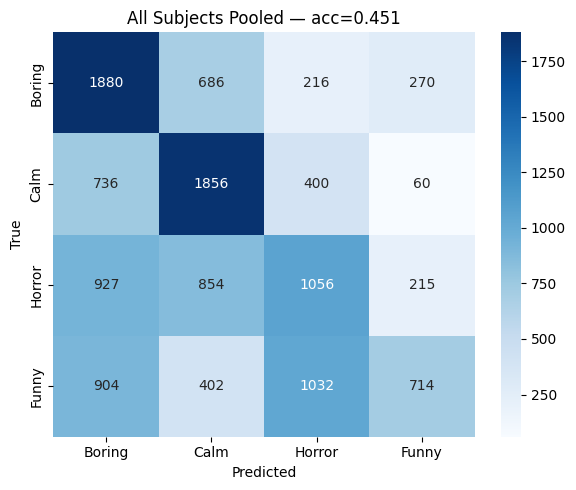

Saved → tda_gameemo_results.csv


In [ ]:
#─ CELL 11: Scale + Train RF ─────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training Random Forest on pooled data...")
clf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy : {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=EMOTION_LABELS))

plot_cm(y_test, y_pred, f"All Subjects Pooled — acc={acc:.3f}")

# Save results
pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
}).to_csv("tda_gameemo_results.csv", index=False)
print("Saved → tda_gameemo_results.csv")
